# Retail Sales Data Analysis & Business Insights

**Dataset:** `samplesuperstore.csv`  
**Tools:** Pandas, NumPy, Matplotlib, Seaborn

### Objectives
- Load and clean retail sales data.
- Handle missing values, duplicate records, and inconsistent data.
- Perform exploratory data analysis (EDA).
- Analyze sales, profit, quantity, and customer statistics.
- Study product, category, customer, and regional performance.
- Visualize trends using bar charts, line charts, scatter plots, and a heatmap.
- Generate practical business insights and observations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)



df = pd.read_csv("samplesuperstore.csv")
print(f"Dataset shape: {df.shape}")
display(df.head())

Dataset shape: (10194, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,State/Province,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,1/3/2023,1/7/2023,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,Texas,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.45,2,0.20,5.55
1,2,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.54,2,0.80,-5.49
2,3,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.78,3,0.20,4.27
3,4,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.74,3,0.20,-64.77
4,5,US-2023-141817,1/5/2023,1/12/2023,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,Pennsylvania,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.54,3,0.20,4.88


## 1. Initial Data Inspection

In [2]:
print("Rows:", len(df))
print("Columns:", len(df.columns))
print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame('dtype'))

print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False).to_frame('missing'))

print("\nDuplicate rows:", df.duplicated().sum())

print("\nBasic numerical summary:")
display(df.describe().T)

Rows: 10194
Columns: 21

Column names:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country/Region', 'City', 'State/Province', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

Data types:


,dtype
Row ID,int64
Order ID,object
Order Date,object
Ship Date,object
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country/Region,object
City,object



Missing values:


,missing
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country/Region,0
City,0



Duplicate rows: 0

Basic numerical summary:


,count,mean,std,min,25%,50%,75%,max
Row ID,"10,194.00","5,097.50","2,942.90",1.00,"2,549.25","5,097.50","7,645.75","10,194.00"
Sales,"10,194.00",228.23,619.91,0.44,17.22,53.91,209.50,"22,638.48"
Quantity,"10,194.00",3.79,2.23,1.00,2.00,3.00,5.00,14.00
Discount,"10,194.00",0.16,0.21,0.00,0.00,0.20,0.20,0.80
Profit,"10,194.00",28.67,232.47,"-6,599.98",1.76,8.69,29.30,"8,399.98"


## 2. Data Cleaning

The cleaning process standardizes column names, removes exact duplicate records, converts dates and numeric fields, trims text fields, and fills missing values using sensible rules.

In [3]:
# Keep a copy so the original imported data remains available for comparison.
clean_df = df.copy()

# Standardize column names
clean_df.columns = (
    clean_df.columns.str.strip()
    .str.lower()
    .str.replace(r'[^a-z0-9]+', '_', regex=True)
    .str.strip('_')
)

# Remove exact duplicate records
before = len(clean_df)
clean_df = clean_df.drop_duplicates().copy()
duplicates_removed = before - len(clean_df)

# Clean text columns
text_cols = clean_df.select_dtypes(include='object').columns
for col in text_cols:
    clean_df[col] = clean_df[col].astype('string').str.strip()
    clean_df[col] = clean_df[col].replace({'': pd.NA, 'nan': pd.NA, 'None': pd.NA})

# Convert dates
for col in ['order_date', 'ship_date']:
    clean_df[col] = pd.to_datetime(clean_df[col], errors='coerce')

# Convert numeric columns
numeric_cols = ['row_id', 'postal_code', 'sales', 'quantity', 'discount', 'profit']
for col in numeric_cols:
    clean_df[col] = pd.to_numeric(clean_df[col], errors='coerce')

# Fill numeric missing values with median
for col in ['sales', 'quantity', 'discount', 'profit']:
    if clean_df[col].isna().any():
        clean_df[col] = clean_df[col].fillna(clean_df[col].median())

# Fill categorical missing values with the mode
for col in ['ship_mode', 'segment', 'region', 'category', 'sub_category']:
    if clean_df[col].isna().any():
        mode = clean_df[col].mode(dropna=True)
        if not mode.empty:
            clean_df[col] = clean_df[col].fillna(mode.iloc[0])

# Fill remaining text/date missing values with explicit labels where appropriate
for col in ['customer_id', 'customer_name', 'country_region', 'city', 'state_province',
            'product_id', 'product_name']:
    if col in clean_df.columns:
        clean_df[col] = clean_df[col].fillna('Unknown')

# Date fields: use the median date if missing
for col in ['order_date', 'ship_date']:
    if clean_df[col].isna().any():
        clean_df[col] = clean_df[col].fillna(clean_df[col].dropna().median())

print("Duplicate rows removed:", duplicates_removed)
print("Cleaned shape:", clean_df.shape)

print("\nMissing values after cleaning:")
display(clean_df.isna().sum().sort_values(ascending=False).to_frame('missing_after_cleaning'))

Duplicate rows removed: 0
Cleaned shape: (10194, 21)

Missing values after cleaning:


,missing_after_cleaning
postal_code,200
order_id,0
order_date,0
ship_date,0
row_id,0
ship_mode,0
customer_id,0
segment,0
customer_name,0
country_region,0


## 3. Consistency Checks and Feature Engineering

In [4]:
# Check for invalid business values
print("Negative sales rows:", (clean_df['sales'] < 0).sum())
print("Negative quantity rows:", (clean_df['quantity'] < 0).sum())
print("Discount outside 0-1:", ((clean_df['discount'] < 0) | (clean_df['discount'] > 1)).sum())

# Standardize common category-like values
for col in ['ship_mode', 'segment', 'region', 'category', 'sub_category']:
    clean_df[col] = clean_df[col].str.replace(r'\s+', ' ', regex=True).str.strip()

# Derived variables
clean_df['year'] = clean_df['order_date'].dt.year
clean_df['month'] = clean_df['order_date'].dt.month
clean_df['month_name'] = clean_df['order_date'].dt.strftime('%b')
clean_df['year_month'] = clean_df['order_date'].dt.to_period('M').astype(str)
clean_df['profit_margin'] = np.where(
    clean_df['sales'] != 0,
    clean_df['profit'] / clean_df['sales'] * 100,
    np.nan
)
clean_df['shipping_days'] = (clean_df['ship_date'] - clean_df['order_date']).dt.days

# Correct obvious negative shipping duration values if any, for analysis purposes
print("Negative shipping days:", (clean_df['shipping_days'] < 0).sum())

display(clean_df.head())

Negative sales rows: 0
Negative quantity rows: 0
Discount outside 0-1: 0
Negative shipping days: 0


,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country_region,city,state_province,postal_code,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit,year,month,month_name,year_month,profit_margin,shipping_days
0,1,US-2023-103800,2023-01-03,2023-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,Texas,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.45,2,0.20,5.55,2023,1,Jan,2023-01,33.75,4
1,2,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.54,2,0.80,-5.49,2023,1,Jan,2023-01,-155.00,4
2,3,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.78,3,0.20,4.27,2023,1,Jan,2023-01,36.25,4
3,4,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.74,3,0.20,-64.77,2023,1,Jan,2023-01,-23.75,4
4,5,US-2023-141817,2023-01-05,2023-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,Pennsylvania,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.54,3,0.20,4.88,2023,1,Jan,2023-01,25.00,7


## 4. Overall Sales, Profit, Quantity and Customer Statistics

In [5]:
total_sales = clean_df['sales'].sum()
total_profit = clean_df['profit'].sum()
total_quantity = clean_df['quantity'].sum()
total_orders = clean_df['order_id'].nunique()
total_customers = clean_df['customer_id'].nunique()
total_products = clean_df['product_id'].nunique()
avg_order_sales = clean_df.groupby('order_id')['sales'].sum().mean()
overall_margin = total_profit / total_sales * 100

summary = pd.Series({
    'Total Sales': total_sales,
    'Total Profit': total_profit,
    'Total Quantity Sold': total_quantity,
    'Unique Orders': total_orders,
    'Unique Customers': total_customers,
    'Unique Products': total_products,
    'Average Sales per Order': avg_order_sales,
    'Overall Profit Margin (%)': overall_margin
})
display(summary.to_frame('Value'))

print("\nCustomer purchase summary:")
customer_stats = clean_df.groupby(['customer_id', 'customer_name']).agg(
    orders=('order_id', 'nunique'),
    sales=('sales', 'sum'),
    profit=('profit', 'sum'),
    quantity=('quantity', 'sum')
).sort_values('sales', ascending=False)

display(customer_stats.head(10))

,Value
Total Sales,"2,326,534.35"
Total Profit,"292,296.81"
Total Quantity Sold,"38,654.00"
Unique Orders,"5,111.00"
Unique Customers,804.00
Unique Products,"1,862.00"
Average Sales per Order,455.20
Overall Profit Margin (%),12.56



Customer purchase summary:


,,orders,sales,profit,quantity
customer_id,customer_name,,,,
SM-20320,Sean Miller,5,"25,043.05","-1,980.74",50
TC-20980,Tamara Chand,5,"19,052.22","8,981.32",42
RB-19360,Raymond Buch,6,"15,117.34","6,976.10",71
TA-21385,Tom Ashbrook,4,"14,595.62","4,703.79",36
AB-10105,Adrian Barton,10,"14,473.57","5,444.81",73
KL-16645,Ken Lonsdale,12,"14,175.23",806.85,113
SC-20095,Sanjit Chand,9,"14,142.33","5,757.41",87
HL-15040,Hunter Lopez,6,"12,873.30","5,622.43",50
SE-20110,Sanjit Engle,11,"12,209.44","2,650.68",78


## 5. Category and Sub-Category Performance

,sales,profit,quantity,orders,profit_margin_%
category,,,,,
Technology,"839,893.28","146,543.38",7017,1560,17.45
Furniture,"754,747.76","19,730.00",8369,1819,2.61
Office Supplies,"731,893.31","126,023.44",23268,3812,17.22


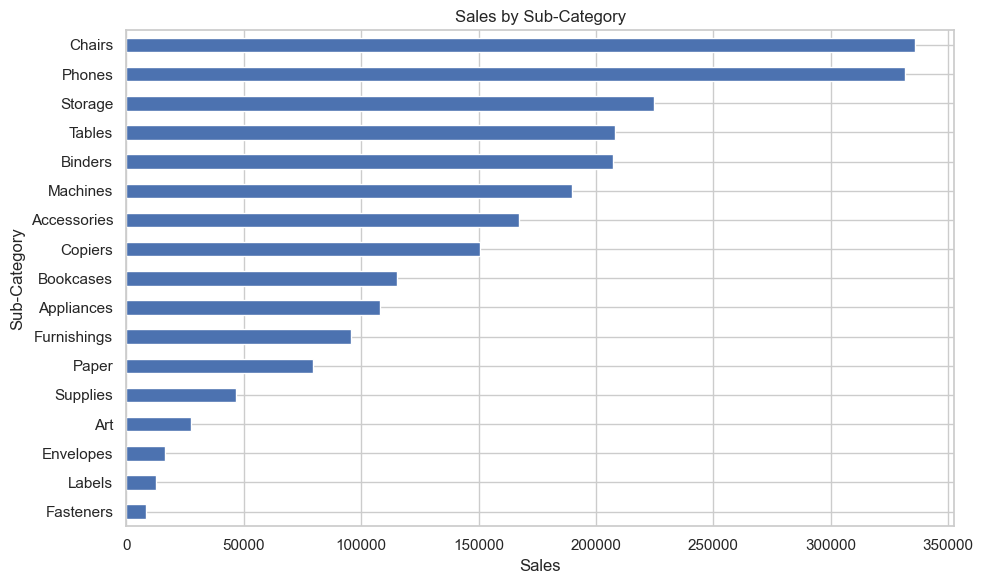

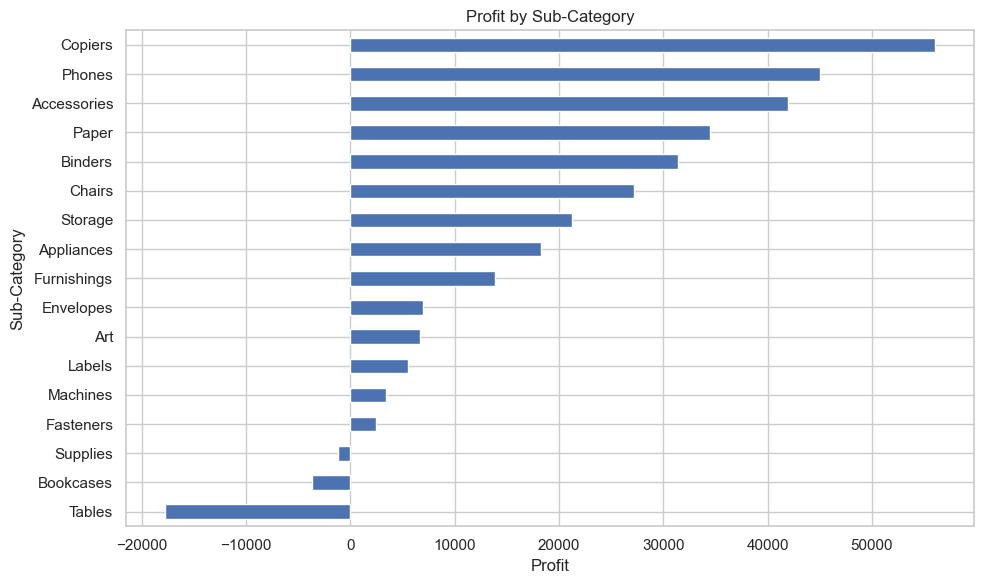

In [6]:
category_perf = clean_df.groupby('category').agg(
    sales=('sales', 'sum'),
    profit=('profit', 'sum'),
    quantity=('quantity', 'sum'),
    orders=('order_id', 'nunique')
).sort_values('sales', ascending=False)

category_perf['profit_margin_%'] = category_perf['profit'] / category_perf['sales'] * 100
display(category_perf)

subcat_perf = clean_df.groupby('sub_category').agg(
    sales=('sales', 'sum'),
    profit=('profit', 'sum'),
    quantity=('quantity', 'sum')
).sort_values('sales', ascending=False)

subcat_perf['profit_margin_%'] = subcat_perf['profit'] / subcat_perf['sales'] * 100

fig, ax = plt.subplots()
subcat_perf['sales'].sort_values().plot(kind='barh', ax=ax)
ax.set_title('Sales by Sub-Category')
ax.set_xlabel('Sales')
ax.set_ylabel('Sub-Category')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots()
subcat_profit = subcat_perf['profit'].sort_values()
subcat_profit.plot(kind='barh', ax=ax)
ax.set_title('Profit by Sub-Category')
ax.set_xlabel('Profit')
ax.set_ylabel('Sub-Category')
plt.tight_layout()
plt.show()

## 6. Regional Performance

,sales,profit,quantity,customers,orders,profit_margin_%
region,,,,,,
West,"739,813.61","110,798.82",12466,686,1635,14.98
East,"691,828.17","94,883.26",11159,685,1475,13.71
Central,"503,170.67","39,865.31",8820,629,1179,7.92
South,"391,721.90","46,749.43",6209,512,822,11.93


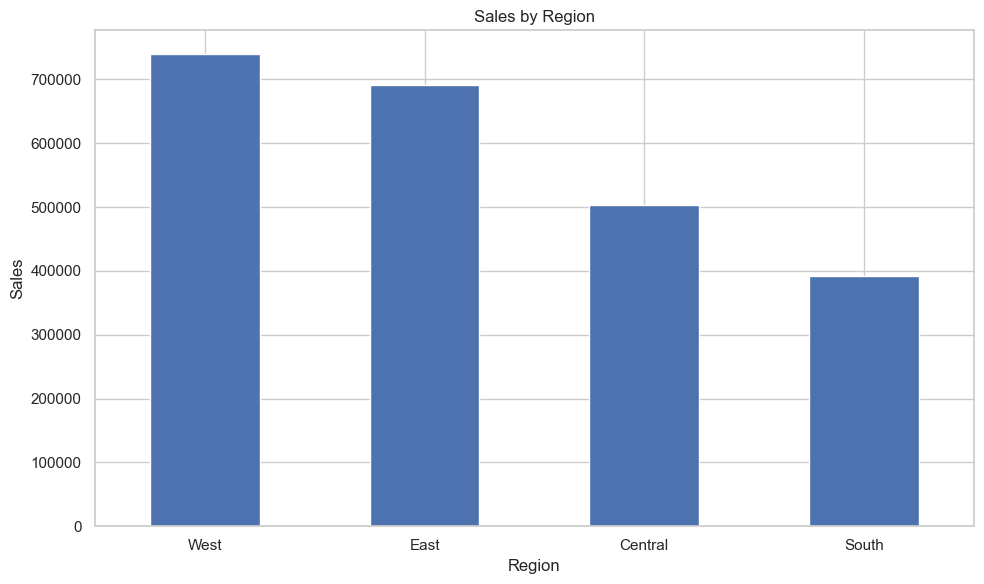

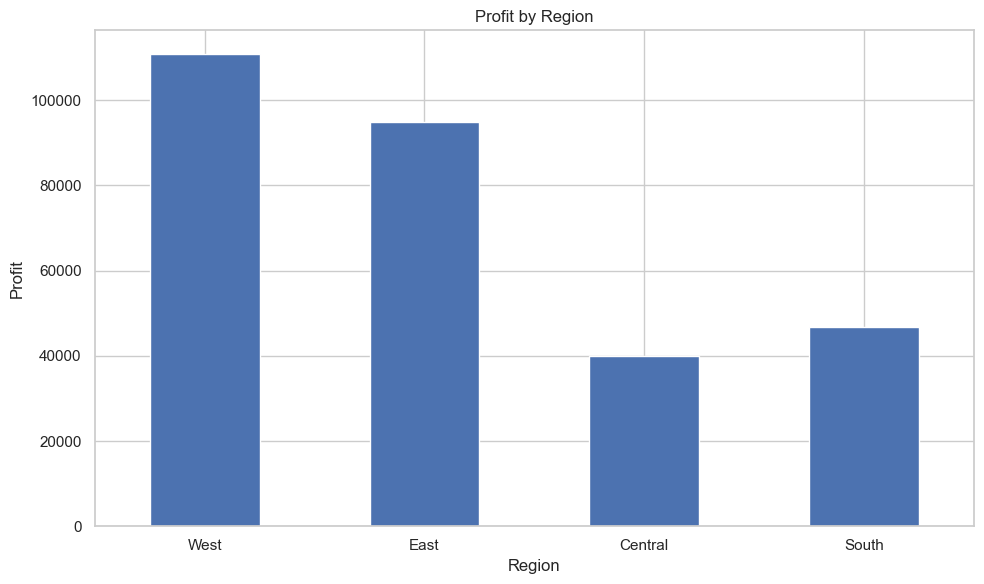

In [7]:
region_perf = clean_df.groupby('region').agg(
    sales=('sales', 'sum'),
    profit=('profit', 'sum'),
    quantity=('quantity', 'sum'),
    customers=('customer_id', 'nunique'),
    orders=('order_id', 'nunique')
).sort_values('sales', ascending=False)

region_perf['profit_margin_%'] = region_perf['profit'] / region_perf['sales'] * 100
display(region_perf)

fig, ax = plt.subplots()
region_perf['sales'].plot(kind='bar', ax=ax)
ax.set_title('Sales by Region')
ax.set_ylabel('Sales')
ax.set_xlabel('Region')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots()
region_perf['profit'].plot(kind='bar', ax=ax)
ax.set_title('Profit by Region')
ax.set_ylabel('Profit')
ax.set_xlabel('Region')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 7. Time-Series Sales and Profit Trend

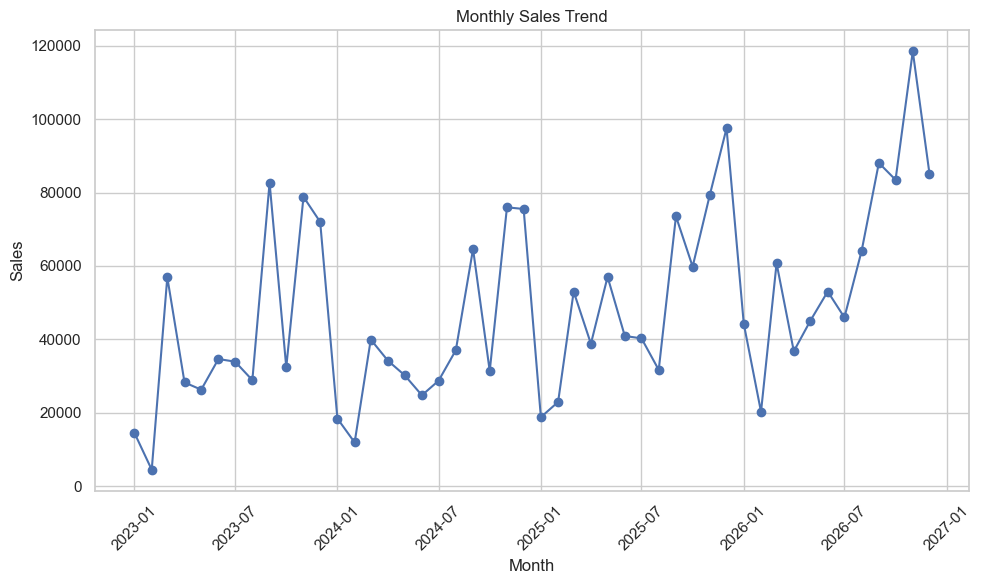

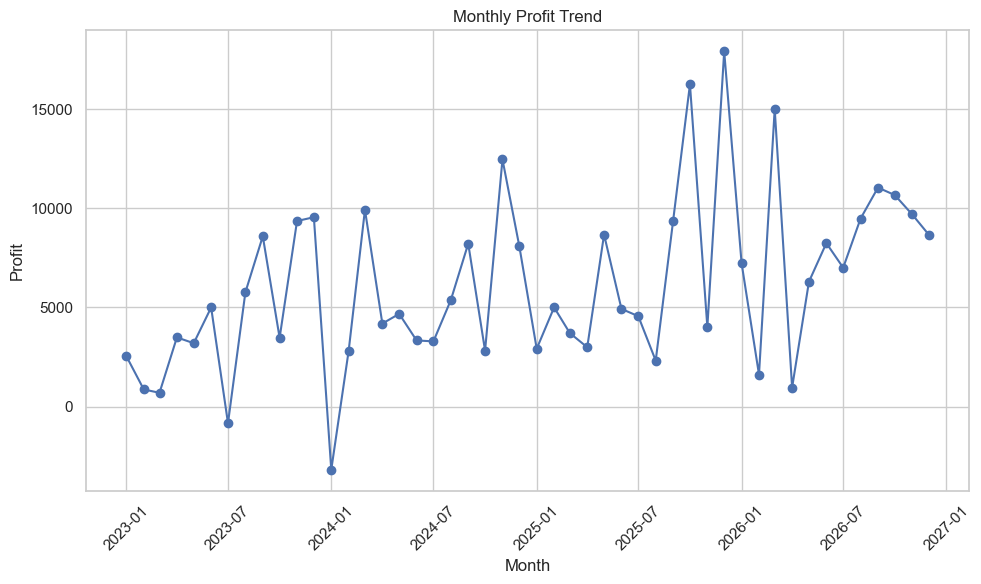

Best sales month:


,Value
year_month,2026-11
sales,"118,454.51"
profit,"9,692.10"


Best profit month:


,Value
year_month,2025-12
sales,"97,502.28"
profit,"17,926.30"


In [8]:
monthly = clean_df.groupby('year_month').agg(
    sales=('sales', 'sum'),
    profit=('profit', 'sum'),
    quantity=('quantity', 'sum')
).reset_index()

monthly['date'] = pd.to_datetime(monthly['year_month'])

fig, ax = plt.subplots()
ax.plot(monthly['date'], monthly['sales'], marker='o')
ax.set_title('Monthly Sales Trend')
ax.set_xlabel('Month')
ax.set_ylabel('Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots()
ax.plot(monthly['date'], monthly['profit'], marker='o')
ax.set_title('Monthly Profit Trend')
ax.set_xlabel('Month')
ax.set_ylabel('Profit')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Best sales month:")
display(monthly.loc[monthly['sales'].idxmax(), ['year_month', 'sales', 'profit']].to_frame('Value'))

print("Best profit month:")
display(monthly.loc[monthly['profit'].idxmax(), ['year_month', 'sales', 'profit']].to_frame('Value'))

## 8. Product Performance

In [9]:
product_perf = clean_df.groupby(['product_id', 'product_name']).agg(
    sales=('sales', 'sum'),
    profit=('profit', 'sum'),
    quantity=('quantity', 'sum'),
    orders=('order_id', 'nunique')
).sort_values('sales', ascending=False)

print("Top 10 products by sales:")
display(product_perf.head(10))

print("Top 10 products by profit:")
display(product_perf.sort_values('profit', ascending=False).head(10))

print("Bottom 10 products by profit:")
display(product_perf.sort_values('profit').head(10))

Top 10 products by sales:


,,sales,profit,quantity,orders
product_id,product_name,,,,
TEC-CO-10004722,Canon imageCLASS 2200 Advanced Copier,"61,599.82","25,199.93",20,5
OFF-BI-10003527,Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,"27,453.38","7,753.04",31,10
TEC-MA-10002412,Cisco TelePresence System EX90 Videoconferencing Unit,"22,638.48","-1,811.08",6,1
FUR-CH-10002024,HON 5400 Series Task Chairs for Big and Tall,"21,870.58",0.00,39,8
OFF-BI-10001359,GBC DocuBind TL300 Electric Binding System,"19,823.48","2,233.51",37,11
OFF-BI-10000545,GBC Ibimaster 500 Manual ProClick Binding System,"19,024.50",760.98,48,9
TEC-CO-10001449,Hewlett Packard LaserJet 3310 Copier,"18,839.69","6,983.88",38,8
TEC-MA-10001127,"HP Designjet T520 Inkjet Large Format Printer - 24"" Color","18,374.90","4,094.98",12,3
OFF-BI-10004995,GBC DocuBind P400 Electric Binding System,"17,965.07","-1,878.17",27,6


Top 10 products by profit:


,,sales,profit,quantity,orders
product_id,product_name,,,,
TEC-CO-10004722,Canon imageCLASS 2200 Advanced Copier,"61,599.82","25,199.93",20,5
OFF-BI-10003527,Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,"27,453.38","7,753.04",31,10
TEC-CO-10001449,Hewlett Packard LaserJet 3310 Copier,"18,839.69","6,983.88",38,8
TEC-CO-10003763,Canon PC1060 Personal Laser Copier,"11,619.83","4,570.93",19,4
TEC-MA-10001127,"HP Designjet T520 Inkjet Large Format Printer - 24"" Color","18,374.90","4,094.98",12,3
TEC-MA-10003979,Ativa V4110MDD Micro-Cut Shredder,"7,699.89","3,772.95",11,2
TEC-MA-10001047,"3D Systems Cube Printer, 2nd Generation, Magenta","14,299.89","3,717.97",11,2
TEC-AC-10002049,Plantronics Savi W720 Multi-Device Wireless Headset System,"9,367.29","3,696.28",24,7
OFF-BI-10001120,Ibico EPK-21 Electric Binding System,"15,875.92","3,345.28",13,3


Bottom 10 products by profit:


,,sales,profit,quantity,orders
product_id,product_name,,,,
TEC-MA-10000418,Cubify CubeX 3D Printer Double Head Print,"11,099.96","-8,879.97",9,3
TEC-MA-10000822,Lexmark MX611dhe Monochrome Laser Printer,"16,829.90","-4,589.97",18,4
TEC-MA-10004125,Cubify CubeX 3D Printer Triple Head Print,"7,999.98","-3,839.99",4,1
FUR-TA-10000198,Chromcraft Bull-Nose Wood Oval Conference Tables & Bases,"9,917.64","-2,876.12",27,5
FUR-TA-10001889,Bush Advantage Collection Racetrack Conference Table,"9,544.73","-1,934.40",33,7
OFF-BI-10004995,GBC DocuBind P400 Electric Binding System,"17,965.07","-1,878.17",27,6
TEC-MA-10002412,Cisco TelePresence System EX90 Videoconferencing Unit,"22,638.48","-1,811.08",6,1
OFF-SU-10002881,Martin Yale Chadless Opener Electric Letter Opener,"16,656.20","-1,299.18",22,6
FUR-TA-10001950,Balt Solid Wood Round Tables,"6,518.75","-1,201.06",19,4


## 9. Customer and Segment Analysis

,sales,profit,quantity,customers,orders,profit_margin_%
segment,,,,,,
Consumer,"1,170,659.79","136,371.45",19844,416,2628,11.65
Corporate,"715,806.13","94,249.64",11898,239,1552,13.17
Home Office,"440,068.43","61,675.73",6912,149,931,14.02


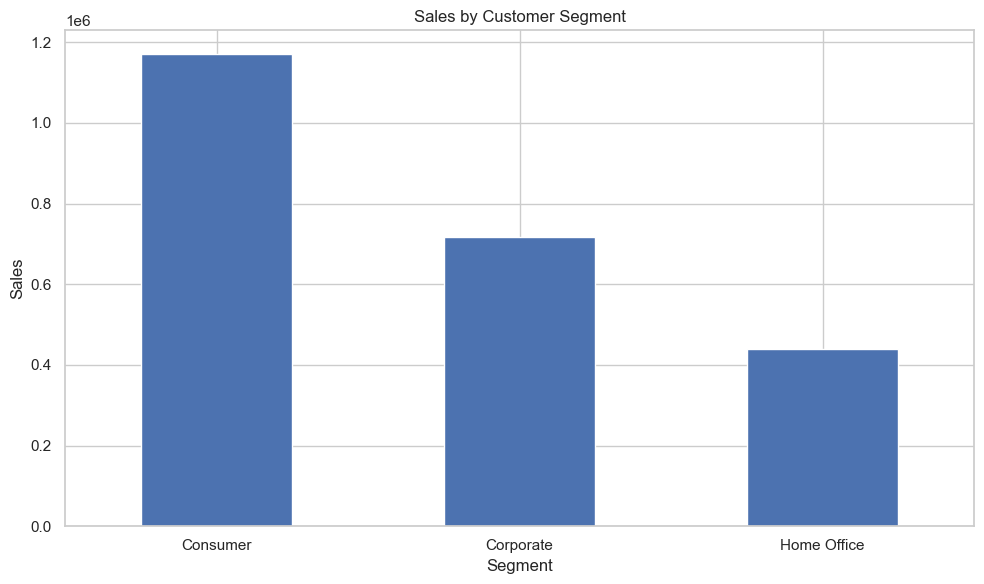

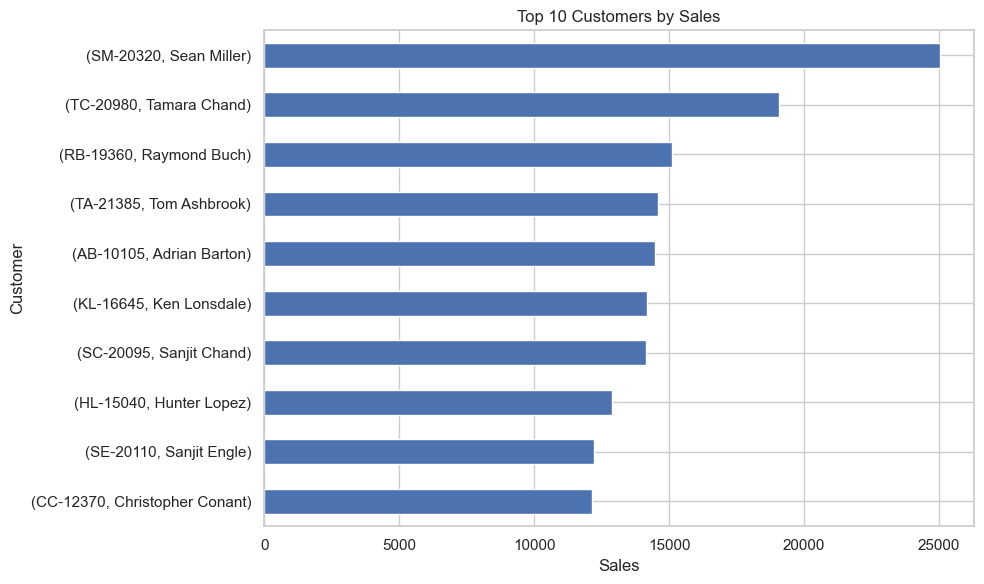

In [10]:
segment_perf = clean_df.groupby('segment').agg(
    sales=('sales', 'sum'),
    profit=('profit', 'sum'),
    quantity=('quantity', 'sum'),
    customers=('customer_id', 'nunique'),
    orders=('order_id', 'nunique')
)
segment_perf['profit_margin_%'] = segment_perf['profit'] / segment_perf['sales'] * 100
display(segment_perf.sort_values('sales', ascending=False))

fig, ax = plt.subplots()
segment_perf['sales'].plot(kind='bar', ax=ax)
ax.set_title('Sales by Customer Segment')
ax.set_ylabel('Sales')
ax.set_xlabel('Segment')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Top customers
top_customers = customer_stats.head(10).sort_values('sales')
fig, ax = plt.subplots()
top_customers['sales'].plot(kind='barh', ax=ax)
ax.set_title('Top 10 Customers by Sales')
ax.set_xlabel('Sales')
ax.set_ylabel('Customer')
plt.tight_layout()
plt.show()

## 10. Sales vs Profit — Scatter Plot

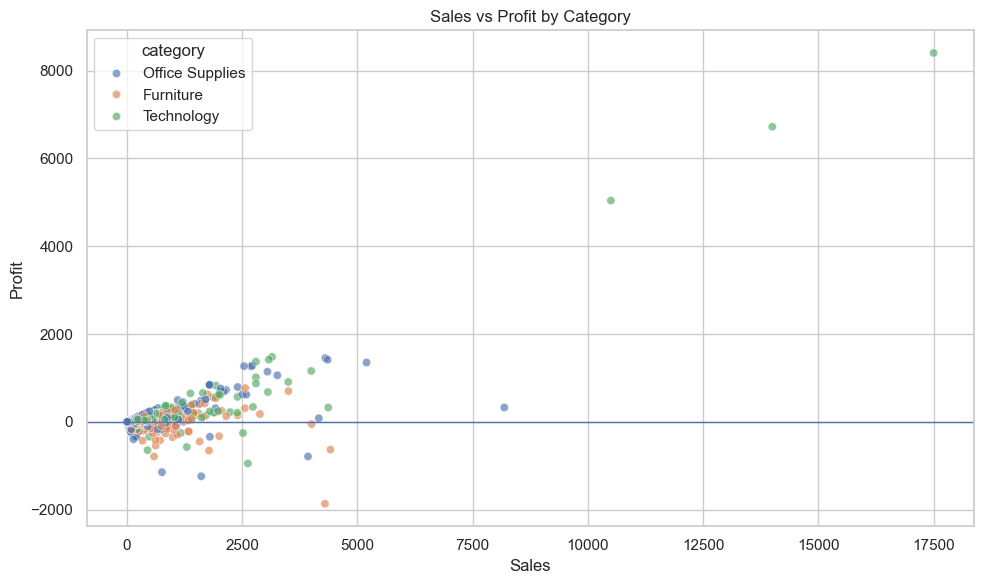

Correlation between Sales and Profit:
0.4814597230192395


In [11]:
fig, ax = plt.subplots()
sample = clean_df.sample(min(2500, len(clean_df)), random_state=42)
sns.scatterplot(data=sample, x='sales', y='profit', hue='category', alpha=0.65, ax=ax)
ax.axhline(0, linewidth=1)
ax.set_title('Sales vs Profit by Category')
ax.set_xlabel('Sales')
ax.set_ylabel('Profit')
plt.tight_layout()
plt.show()

print("Correlation between Sales and Profit:")
print(clean_df[['sales', 'profit']].corr().iloc[0, 1])

## 11. Correlation Heatmap

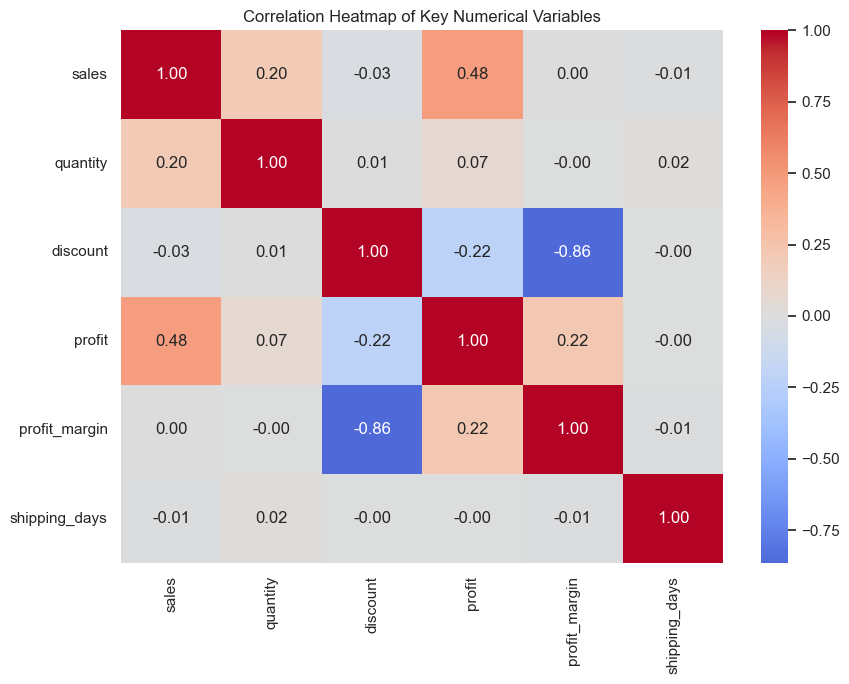

In [12]:
corr_cols = ['sales', 'quantity', 'discount', 'profit', 'profit_margin', 'shipping_days']
corr = clean_df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Heatmap of Key Numerical Variables')
plt.tight_layout()
plt.show()

## 12. Discount and Profitability Analysis

,sales,profit,quantity,rows,profit_margin_%
discount,,,,,
"(-0.002, 0.0]","1,105,323.79","326,718.59",18770,4925,29.56
"(0.0, 0.1]","54,952.50","9,099.97",377,96,16.56
"(0.1, 0.2]","801,497.92","92,498.94",14054,3758,11.54
"(0.2, 0.3]","104,474.07","-10,513.45",855,230,-10.06
"(0.3, 0.4]","130,991.22","-25,477.51",894,234,-19.45
"(0.4, 0.6]","71,509.45","-29,163.89",840,226,-40.78
"(0.6, 1.0]","57,785.41","-70,865.84",2864,725,-122.64


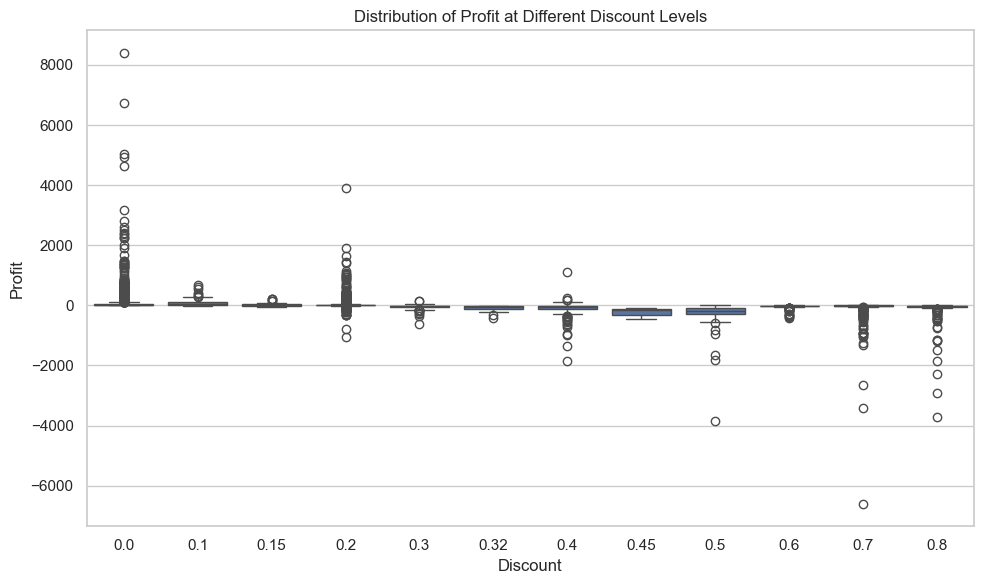

In [13]:
discount_bins = pd.cut(
    clean_df['discount'],
    bins=[-0.001, 0, 0.10, 0.20, 0.30, 0.40, 0.60, 1.0],
    include_lowest=True
)

discount_perf = clean_df.groupby(discount_bins, observed=False).agg(
    sales=('sales', 'sum'),
    profit=('profit', 'sum'),
    quantity=('quantity', 'sum'),
    rows=('profit', 'size')
)
discount_perf['profit_margin_%'] = discount_perf['profit'] / discount_perf['sales'] * 100
display(discount_perf)

fig, ax = plt.subplots()
sns.boxplot(data=clean_df, x='discount', y='profit', ax=ax)
ax.set_title('Distribution of Profit at Different Discount Levels')
ax.set_xlabel('Discount')
ax.set_ylabel('Profit')
plt.tight_layout()
plt.show()

## 13. Key Business Insights

In [14]:
# Generate data-driven observations automatically from the cleaned dataset.

best_category = category_perf['sales'].idxmax()
best_category_profit = category_perf['profit'].idxmax()
best_region = region_perf['sales'].idxmax()
best_region_profit = region_perf['profit'].idxmax()
best_segment = segment_perf['sales'].idxmax()
best_month = monthly.loc[monthly['sales'].idxmax(), 'year_month']
top_product = product_perf.index[0][1]
top_profit_product = product_perf.sort_values('profit', ascending=False).index[0][1]
worst_profit_product = product_perf.sort_values('profit').index[0][1]

high_discount = discount_perf.loc[discount_perf.index.astype(str).str.contains('0.4|0.6|1.0', regex=True), 'profit'].sum()

insights = [
    f"1. {best_category} generates the highest total sales among categories.",
    f"2. {best_category_profit} generates the highest total profit among categories, so sales leadership and profit leadership should be evaluated separately.",
    f"3. {best_region} is the strongest region by total sales, while {best_region_profit} is the strongest by total profit.",
    f"4. {best_segment} is the largest customer segment by sales.",
    f"5. {best_month} is the highest-sales month in the available time period, indicating a useful period for inventory and campaign planning.",
    f"6. The top product by sales is '{top_product}'.",
    f"7. The top product by profit is '{top_profit_product}', while '{worst_profit_product}' has the lowest total product-level profit.",
    "8. The Sales vs Profit scatter plot helps identify products/orders with high revenue but weak or negative profitability.",
    "9. Discount should be managed carefully: high discounts can increase sales volume while reducing profit margin. The discount analysis above should be used to set category-specific discount limits.",
    "10. Regional, segment, customer and product-level performance should be reviewed together rather than relying only on total sales."
]

print("\n".join(insights))

1. Technology generates the highest total sales among categories.
2. Technology generates the highest total profit among categories, so sales leadership and profit leadership should be evaluated separately.
3. West is the strongest region by total sales, while West is the strongest by total profit.
4. Consumer is the largest customer segment by sales.
5. 2026-11 is the highest-sales month in the available time period, indicating a useful period for inventory and campaign planning.
6. The top product by sales is 'Canon imageCLASS 2200 Advanced Copier'.
7. The top product by profit is 'Canon imageCLASS 2200 Advanced Copier', while 'Cubify CubeX 3D Printer Double Head Print' has the lowest total product-level profit.
8. The Sales vs Profit scatter plot helps identify products/orders with high revenue but weak or negative profitability.
9. Discount should be managed carefully: high discounts can increase sales volume while reducing profit margin. The discount analysis above should be used 

## 14. Recommendations

Based on the analysis, the following actions can improve business performance:

1. **Protect profitable products:** Give more visibility and inventory priority to products with strong profit and sales.
2. **Review loss-making products:** Investigate products with negative profit and decide whether pricing, discounting, sourcing, or assortment changes are required.
3. **Control discounts:** Avoid blanket discounting. Use historical profitability to set discount thresholds by product/category.
4. **Focus on strong regions:** Replicate successful sales practices from high-performing regions while diagnosing weaker regions.
5. **Develop customer segments:** Tailor promotions and retention campaigns to the largest and most profitable customer segments.
6. **Plan for seasonal demand:** Use the monthly sales trend to improve inventory, staffing, and promotional planning around high-demand periods.
7. **Monitor both sales and profit:** Revenue growth alone does not guarantee better business performance; profit margin should remain a core KPI.

### Conclusion

The cleaned Superstore dataset provides a useful view of sales, profitability, customers, products, categories, regions, discounts, and time trends. The combination of descriptive statistics and visual analysis reveals where revenue is generated, where profit is created or lost, and which areas deserve management attention.

### Optional: Save the cleaned dataset

In [15]:
clean_df.to_csv('cleaned_superstore.csv', index=False)
print("Saved cleaned data to: cleaned_superstore.csv")

Saved cleaned data to: cleaned_superstore.csv
